## Patient Feedback NLP Analysis - WebMD Drug Reviews


In [2]:
!pip install textblob

  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 21.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.5 MB/s  0:00:00
Using cached click-8.3.1-py3-none-any.whl (108 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [textblob]2/4 [nltk]


In [4]:
!pip install WordCloud

In [5]:
# Imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import string
import warnings
from collections import Counter

from textblob import TextBlob
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [7]:
# Load and reading Dataset

df = pd.read_csv("webmd.csv")

print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())



Shape: (362806, 12)


,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,Sides,UsefulCount
0,75 or over,Stuffy Nose,9/21/2014,25dph-7.5peh,146724,5,5,I'm a retired physician and of all the meds I ...,5,Male,"Drowsiness, dizziness , dry mouth /nose/thro...",0
1,25-34,Cold Symptoms,1/13/2011,25dph-7.5peh,146724,5,5,cleared me right up even with my throat hurtin...,5,Female,"Drowsiness, dizziness , dry mouth /nose/thro...",1
2,65-74,Other,7/16/2012,warfarin (bulk) 100 % powder,144731,2,3,why did my PTINR go from a normal of 2.5 to ov...,3,Female,,0
3,75 or over,Other,9/23/2010,warfarin (bulk) 100 % powder,144731,2,2,FALLING AND DON'T REALISE IT,1,Female,,0
4,35-44,Other,1/6/2009,warfarin (bulk) 100 % powder,144731,1,1,My grandfather was prescribed this medication ...,1,Male,,1



Columns:
['Age', 'Condition', 'Date', 'Drug', 'DrugId', 'EaseofUse', 'Effectiveness', 'Reviews', 'Satisfaction', 'Sex', 'Sides', 'UsefulCount']


In [8]:
# detect Important Columns

def find_col(columns, candidates):
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

review_col = find_col(df.columns, ["review", "reviews", "comment", "comments", "text"])
rating_col = find_col(df.columns, ["rating", "ratings", "score"])
drug_col = find_col(df.columns, ["drugName", "drug", "medicine", "medication"])
condition_col = find_col(df.columns, ["condition", "medical_condition", "disease"])

print("Detected columns:")
print("review_col   =", review_col)
print("rating_col   =", rating_col)
print("drug_col     =", drug_col)
print("condition_col=", condition_col)

if review_col is None:
    raise ValueError("No review text column detected. Please set review_col manually.")


Detected columns:
review_col   = Reviews
rating_col   = None
drug_col     = Drug
condition_col= Condition


In [9]:
# 4. Dataset Overview

print("\nInfo:")
df.info()

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

# Keep rows with actual review text
df = df.dropna(subset=[review_col]).copy()
df[review_col] = df[review_col].astype(str)

print("\nShape after dropping missing reviews:", df.shape)



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 362806 entries, 0 to 362805
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Age            362806 non-null  object
 1   Condition      362806 non-null  object
 2   Date           362806 non-null  object
 3   Drug           362806 non-null  object
 4   DrugId         362806 non-null  int64 
 5   EaseofUse      362806 non-null  int64 
 6   Effectiveness  362806 non-null  int64 
 7   Reviews        362763 non-null  object
 8   Satisfaction   362806 non-null  int64 
 9   Sex            362806 non-null  object
 10  Sides          362806 non-null  object
 11  UsefulCount    362806 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 33.2+ MB

Missing values:


Reviews          43
Age               0
Condition         0
Date              0
Drug              0
DrugId            0
EaseofUse         0
Effectiveness     0
Satisfaction      0
Sex               0
Sides             0
UsefulCount       0
dtype: int64


Shape after dropping missing reviews: (362763, 12)


In [10]:
 #Text Cleaning

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\\S+|www\\S+|https\\S+", "", text)
    text = re.sub(r"\\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\\s+", " ", text).strip()
    return text

df["clean_review"] = df[review_col].apply(clean_text)
df = df[df["clean_review"].str.len() > 0].copy()

display(df[[review_col, "clean_review"]].head())



,Reviews,clean_review
0,I'm a retired physician and of all the meds I ...,im a retired physician and of all the meds i h...
1,cleared me right up even with my throat hurtin...,cleared me right up even with my throat hurtin...
2,why did my PTINR go from a normal of 2.5 to ov...,why did my ptinr go from a normal of 25 to ove...
3,FALLING AND DON'T REALISE IT,falling and dont realise it
4,My grandfather was prescribed this medication ...,my grandfather was prescribed this medication ...



Review length summary:


,char_count,word_count
count,320885.000000,320885.000000
mean,326.760335,62.839048
std,309.285165,59.538733
min,1.000000,1.000000
25%,115.000000,22.000000
50%,237.000000,45.000000
75%,432.000000,83.000000
max,3032.000000,534.000000


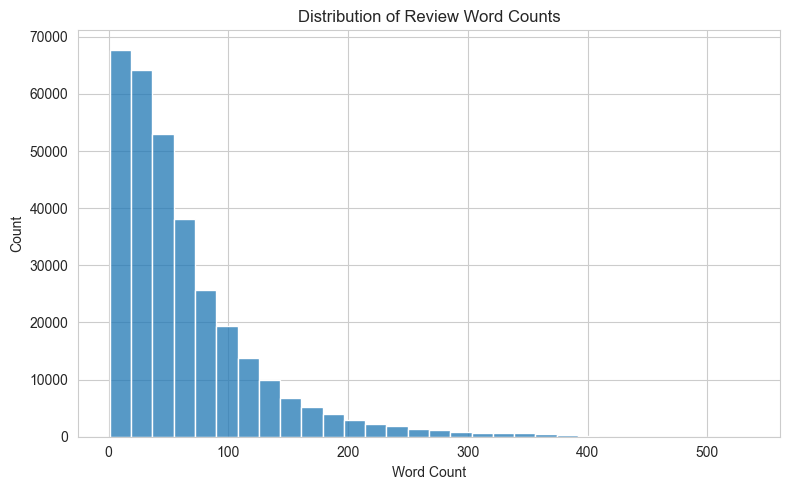

In [11]:
#  Review Length Analysis

df["char_count"] = df["clean_review"].apply(len)
df["word_count"] = df["clean_review"].apply(lambda x: len(x.split()))

print("\nReview length summary:")
display(df[["char_count", "word_count"]].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df["word_count"], bins=30)
plt.title("Distribution of Review Word Counts")
plt.xlabel("Word Count")
plt.tight_layout()
plt.show()



,Word,Count
0,pain,106274
1,side,84601
2,drug,78244
3,day,76549
4,all,74129
5,now,73688
6,medication,72961
7,effects,67085
8,years,60593
9,like,59113


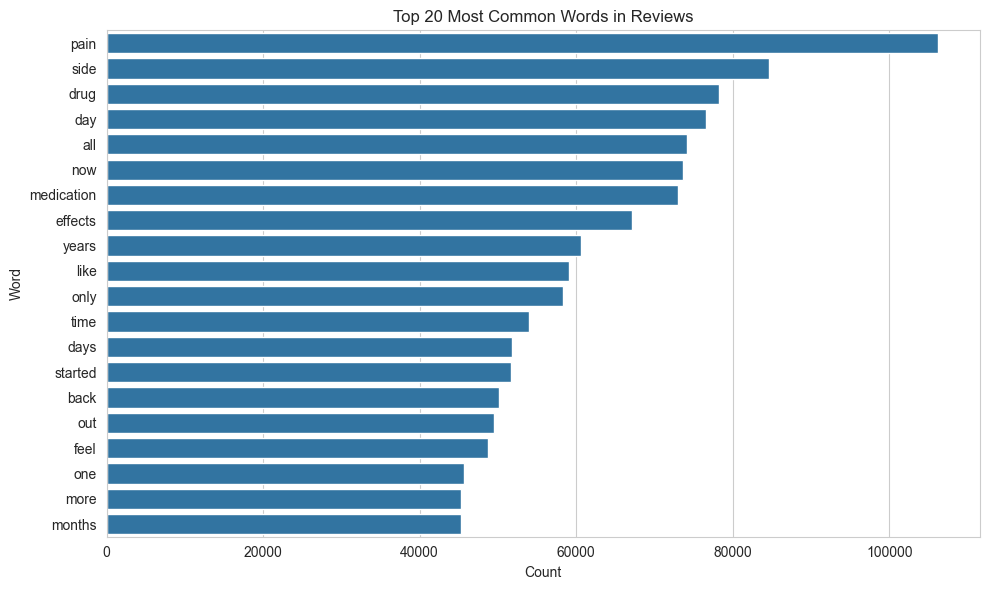

In [12]:
#Most Common Words

basic_stopwords = {
    "the","and","is","in","it","to","of","for","on","this","that","was","with","my","at","a","an",
    "very","had","have","has","be","been","were","are","am","as","but","if","or","so","they","their",
    "them","he","she","his","her","we","our","you","your","i","me","us","from","by","about","would",
    "could","should","can","will","just","not","no","yes","there","here","than","then","too","also",
    "after","before","because","when","while","got","get","getting","taking","take","took"
}

all_words = " ".join(df["clean_review"]).split()
filtered_words = [w for w in all_words if w not in basic_stopwords and len(w) > 2]

word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=["Word", "Count"])

display(common_words)

plt.figure(figsize=(10, 6))
sns.barplot(data=common_words, x="Count", y="Word")
plt.title("Top 20 Most Common Words in Reviews")
plt.tight_layout()
plt.show()


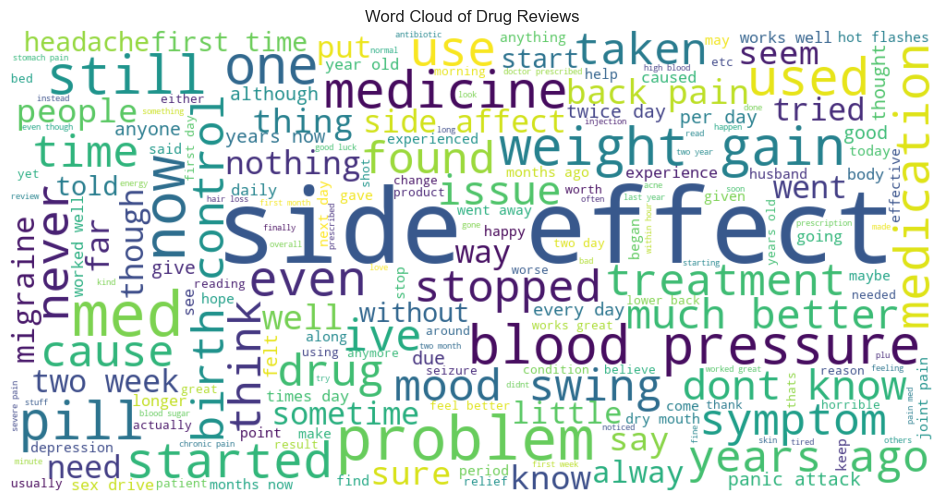

In [13]:
# Word Cloud

wordcloud_text = " ".join(filtered_words)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(wordcloud_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Drug Reviews")
plt.show()




Sentiment distribution:


sentiment_label
Neutral     149698
Positive    109549
Negative     61638
Name: count, dtype: int64

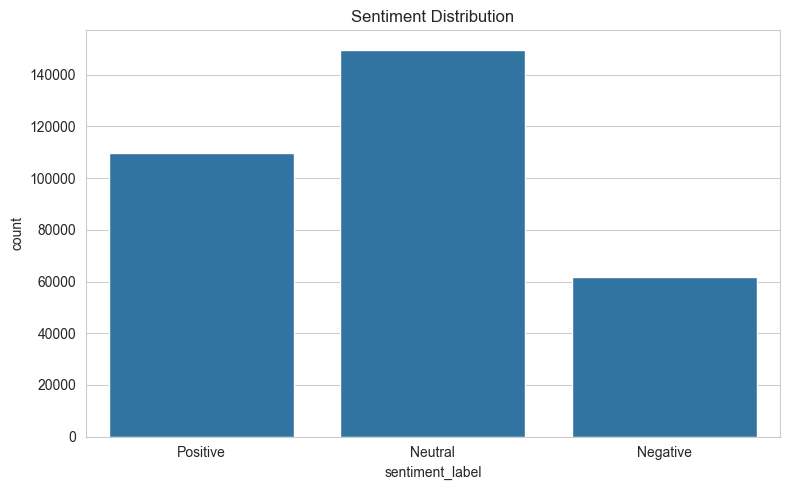

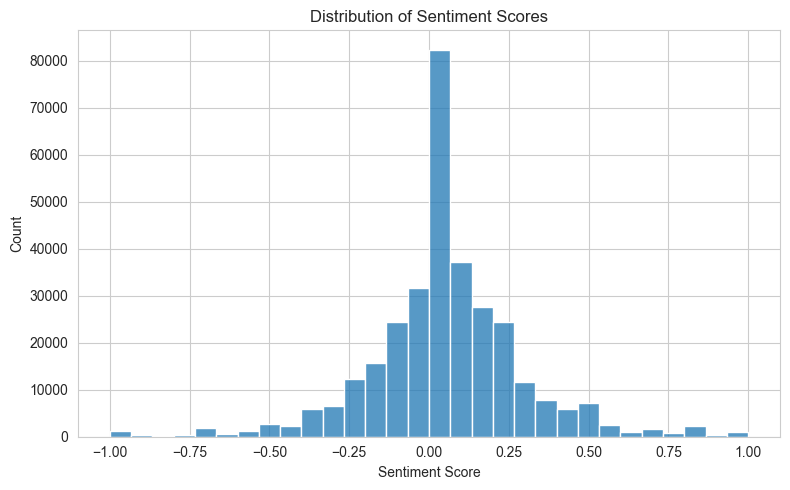

In [14]:
#Sentiment Analysis (TextBlob)

def polarity(text):
    return TextBlob(text).sentiment.polarity

df["sentiment_score"] = df["clean_review"].apply(polarity)

def sentiment_bucket(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    return "Neutral"

df["sentiment_label"] = df["sentiment_score"].apply(sentiment_bucket)

print("\nSentiment distribution:")
display(df["sentiment_label"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x="sentiment_label", data=df, order=["Positive", "Neutral", "Negative"])
plt.title("Sentiment Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["sentiment_score"], bins=30)
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.tight_layout()
plt.show()


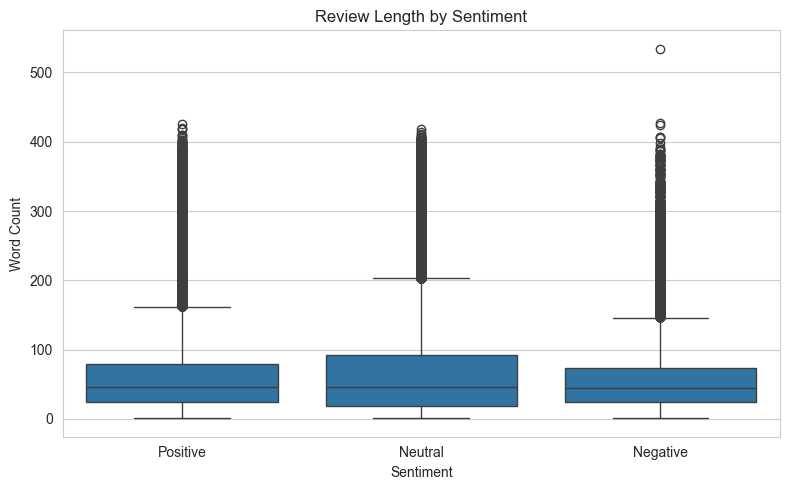

In [15]:
#  Review Length by Sentiment

plt.figure(figsize=(8, 5))
sns.boxplot(x="sentiment_label", y="word_count", data=df, order=["Positive", "Neutral", "Negative"])
plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")
plt.tight_layout()
plt.show()



Top 15 Conditions:


Condition
Other                                            45762
Pain                                             20373
High Blood Pressure                              19406
Depression                                       12696
Birth Control                                    11941
Neuropathic Pain                                  7604
Chronic Trouble Sleeping                          6516
Type 2 Diabetes Mellitus                          6366
Attention Deficit Disorder with Hyperactivity     6014
Bipolar Depression                                5259
Migraine Prevention                               4531
Panic Disorder                                    4149
Major Depressive Disorder                         3865
Overweight                                        3642
Repeated Episodes of Anxiety                      3588
Name: count, dtype: int64

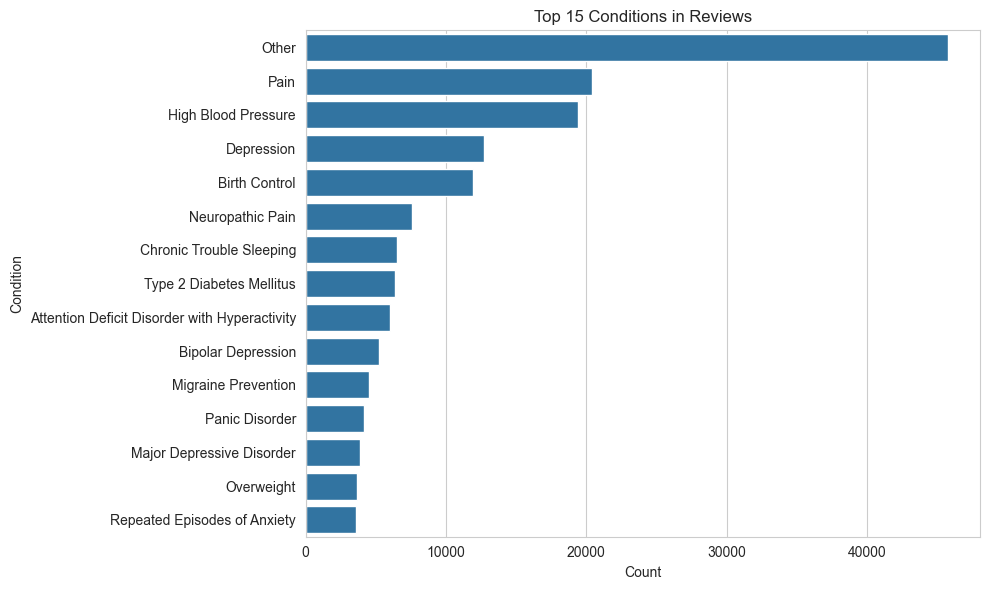


Top 15 Drugs:


Drug
cymbalta                                               4146
lexapro                                                3565
lisinopril                                             3484
lisinopril solution                                    3484
effexor xr                                             3085
hydrocodone-acetaminophen                              2973
lyrica                                                 2778
tramadol hcl                                           2519
tramadol hcl er                                        2519
zoloft                                                 2308
prednisone                                             2285
prednisone tablet, delayed release (enteric coated)    2285
prednisone concentrate                                 2285
phentermine hcl                                        2226
seroquel                                               2193
Name: count, dtype: int64

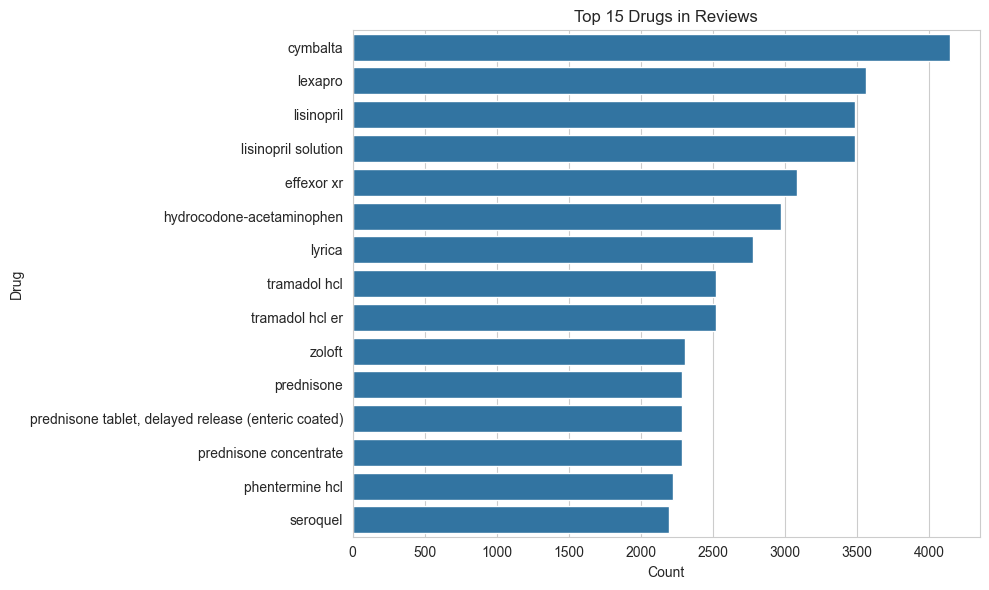

In [16]:
# Top Conditions and Drugs

if condition_col is not None:
    print("\nTop 15 Conditions:")
    display(df[condition_col].value_counts().head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=df[condition_col].value_counts().head(15).values,
        y=df[condition_col].value_counts().head(15).index
    )
    plt.title("Top 15 Conditions in Reviews")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

if drug_col is not None:
    print("\nTop 15 Drugs:")
    display(df[drug_col].value_counts().head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=df[drug_col].value_counts().head(15).values,
        y=df[drug_col].value_counts().head(15).index
    )
    plt.title("Top 15 Drugs in Reviews")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()


In [17]:
# Average Rating by Condition / Drug

if rating_col is not None:
    df[rating_col] = pd.to_numeric(df[rating_col], errors="coerce")

    if condition_col is not None:
        top_condition_ratings = (
            df.groupby(condition_col)[rating_col]
              .mean()
              .sort_values(ascending=False)
              .head(10)
        )

        plt.figure(figsize=(10, 6))
        sns.barplot(x=top_condition_ratings.values, y=top_condition_ratings.index)
        plt.title("Top 10 Average Ratings by Condition")
        plt.xlabel("Average Rating")
        plt.tight_layout()
        plt.show()

    if drug_col is not None:
        drug_counts = df[drug_col].value_counts()
        frequent_drugs = drug_counts[drug_counts >= 20].index

        top_drug_ratings = (
            df[df[drug_col].isin(frequent_drugs)]
            .groupby(drug_col)[rating_col]
            .mean()
            .sort_values(ascending=False)
            .head(10)
        )

        plt.figure(figsize=(10, 6))
        sns.barplot(x=top_drug_ratings.values, y=top_drug_ratings.index)
        plt.title("Top 10 Average Ratings by Drug (min 20 reviews)")
        plt.xlabel("Average Rating")
        plt.tight_layout()
        plt.show()



In [20]:
#  Example Reviews

print("\nExample Positive Reviews:")
display(df[df["sentiment_label"] == "Positive"][[review_col, "sentiment_score"]].head(5))

print("\nExample Negative Reviews:")
display(df[df["sentiment_label"] == "Negative"][[review_col, "sentiment_score"]].head(5))




Example Positive Reviews:


,Reviews,sentiment_score
0,I'm a retired physician and of all the meds I ...,0.337500
1,cleared me right up even with my throat hurtin...,0.285714
2,why did my PTINR go from a normal of 2.5 to ov...,0.150000
10,Excellent in reducing inlamation associated wi...,1.000000
15,The birth control was very easy to use and it ...,0.105522



Example Negative Reviews:


,Reviews,sentiment_score
11,Taking Lyza made me break out HORRIBLY. I trie...,-0.128333
12,This stuff needs to be removed from the market...,-0.420000
13,"I usually have zero to little acne, a few mont...",-0.457305
16,LYZA BIRTH CONTROL\nThese are the WORST birth ...,-0.296970
17,Iâ??ve been taking Lyza for years now and I ab...,-0.235615


## Key Insights

1. Review text can be used to analyze patient sentiment and recurring themes in drug experiences.
2. Topic modeling helps surface common themes such as effectiveness, side effects, symptom relief, or adverse reactions.
3. Ratings provide a useful supervised target for building a simple sentiment classifier.

